# 1. Library Imports

In [7]:
from preprocessing import load_from_url, compute_statistics, standardize, create_windows
from train import train, evaluate, fit_gaussian, compute_threshold
from model import LSTMAutoencoder
import matplotlib.pyplot as plt
import numpy as np
import os

# 2. Data Ingestion

In [8]:
url_normal = "https://raw.githubusercontent.com/numenta/NAB/master/data/artificialNoAnomaly/art_daily_small_noise.csv"
url_anomaly = "https://raw.githubusercontent.com/numenta/NAB/master/data/artificialWithAnomaly/art_daily_jumpsup.csv"

data_normal = load_from_url(url_normal)
data_anomaly = load_from_url(url_anomaly)

mu, sigma = compute_statistics(data_normal)

norm_train = standardize(data_normal, mu, sigma)
norm_test = standardize(data_anomaly, mu, sigma)

# 3. Data Visualization

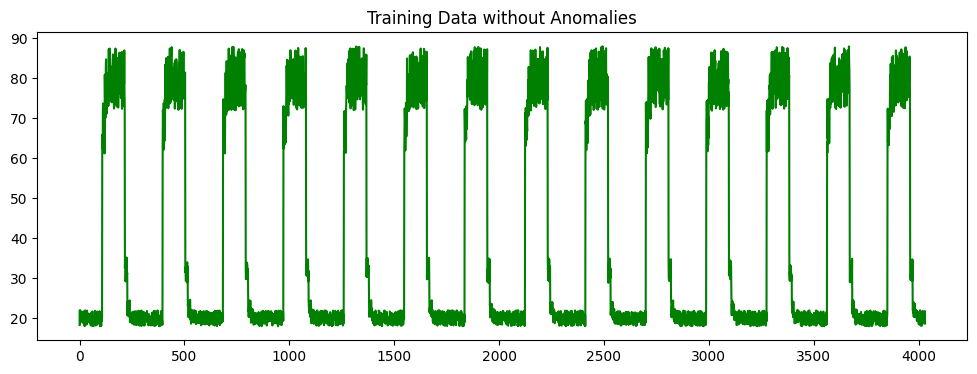

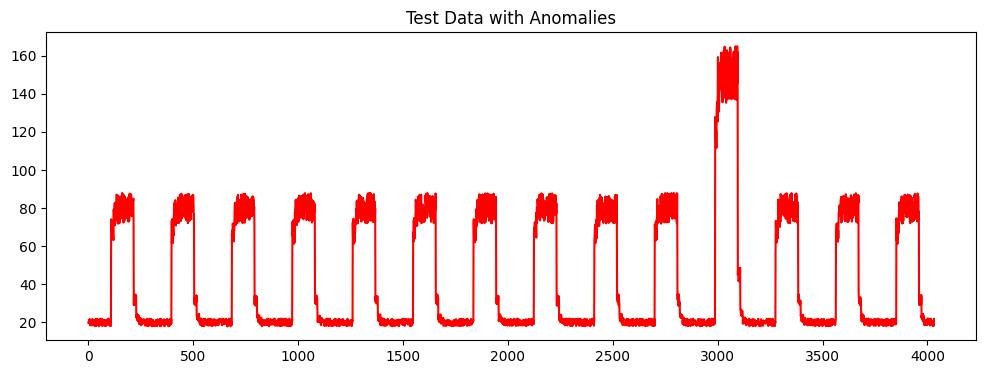

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(data_normal, color='green')
ax.set_title('Training Data without Anomalies')
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(data_anomaly, color='red')
ax.set_title('Test Data with Anomalies')
plt.show()

# 4. Window Construction

In [10]:
T = 288
train_windows_full = create_windows(norm_train, T)
train_windows = train_windows_full[:]
test_windows = create_windows(norm_test, T)

split_idx = int(len(train_windows) * 0.8)
X_train = train_windows[:split_idx]
X_val = train_windows[split_idx:]

# 5. Model Training

In [11]:
p = 32
q = 32
epochs = 10
learning_rate = 0.01
weight_file = "weights.npz"

model = LSTMAutoencoder(seq_len=T, p=p, q=q)

if os.path.exists(weight_file):
    print("Loading weights and history...")
    loss_history = model.load_model(weight_file)
else:
    print("Starting training...")
    loss_history = train(model, X_train, epochs, learning_rate)
    model.save_model(weight_file, history=loss_history)

Starting training...


# 6. Anomaly Scoring

In [12]:
trained_model = LSTMAutoencoder(seq_len=T, p=p, q=q)
trained_model.load_model("weights.npz")

train_errors = evaluate(model, X_train)
mu_e, sigma_e = fit_gaussian(train_errors)

tau = compute_threshold(mu_e, sigma_e, z_score=2.326)

test_errors = evaluate(model, test_windows)
anomaly_labels = (test_errors > tau).astype(int)

# 7. Training Loss Curve

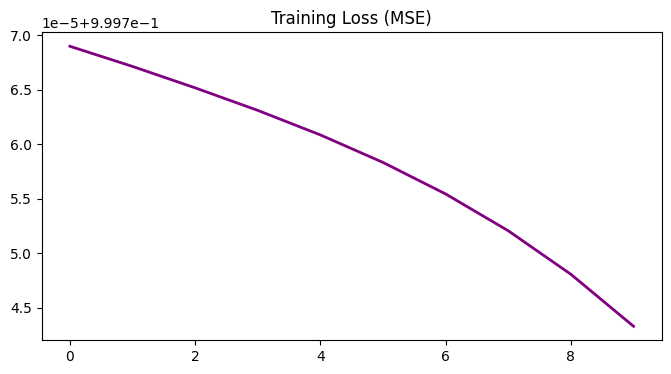

In [13]:
if loss_history is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(loss_history, color='purple', linewidth=2)
    ax.set_title('Training Loss (MSE)')
    plt.show()
else:
    print("No loss history found in the loaded file.")

# 8. Reconstruction Comparison

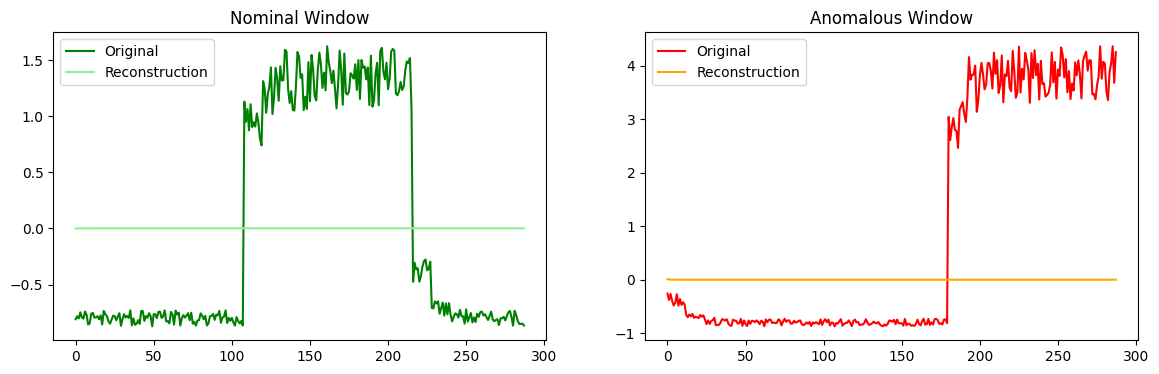

In [14]:
idx_normal = 0
idx_anomaly = np.argmax(test_errors)

w_normal = test_windows[idx_normal]
r_normal, _, _, _ = trained_model.forward(w_normal)

w_anomaly = test_windows[idx_anomaly]
r_anomaly, _, _, _ = trained_model.forward(w_anomaly)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(w_normal, color='green', label='Original')
axes[0].plot(r_normal, color='lightgreen', label='Reconstruction')
axes[0].set_title('Nominal Window')
axes[0].legend()

axes[1].plot(w_anomaly, color='red', label='Original')
axes[1].plot(r_anomaly, color='orange', label='Reconstruction')
axes[1].set_title('Anomalous Window')
axes[1].legend()
plt.show()